# Imports

## Switch to CPU

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"
import warnings
warnings.filterwarnings('ignore')

In [6]:
from scipy import optimize, interpolate

In [1]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pickle
from joblib import dump, load
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_error, explained_variance_score, mean_absolute_error

In [3]:
import copy
import tensorflow as tf
from tensorflow import keras
from keras import backend as K

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.linear_model import LinearRegression

## Switch to GPU

In [9]:
physical_device = tf.config.experimental.list_physical_devices('GPU')
print(f'Device found : {physical_device}')

Device found : []


In [ ]:
tf.config.experimental.set_memory_growth(physical_device[0],True)
tf.config.experimental.get_memory_growth(physical_device[0])

# Gathering the Data

In [17]:
desired_columns = ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "acc", "wind_speed_2", "wind_dir_cos_2", "wind_dir_sin_2", "theta_2", "sigma_2", "delta_2", "roll_2", "climb_angle_2", "Vg_3", "Vc_3", "wind_speed_3", "wind_dir_cos_3", "wind_dir_sin_3", "theta_3", "sigma_3", "delta_3", "roll_3", "climb_angle_3", "Total_Weight"]

## Train

In [319]:
Data_dir = "E:\Work\Doing\B737-800-CFM56-7B24\Data\Departures"
f_lst = []
for f in os.listdir(Data_dir):
    if ".csv" in f:
        f_lst.append(os.path.join(Data_dir, f))

In [ ]:
info_lst_1 = []
info_lst_2 = []
for f in f_lst:
    data_temp = pd.read_csv(f)
    val_1 = data_temp[data_temp["Segment"]=="Slow_Level"].iloc[-20:]["vpath"].mean()
    val_2 = data_temp[data_temp["Segment"]=="Fast_Level"].iloc[-20:]["vpath"].mean()
    if not np.isnan(val_1):
        info_lst_1.append(val_1)
    if not np.isnan(val_2):
        info_lst_2.append(val_2)

In [121]:
np.mean(info_lst_1)

-0.10051282091218518

In [122]:
np.mean(info_lst_2)

0.019086530104828015

In [320]:
Data_Weight = pd.DataFrame(columns = desired_columns)
plot_flag = 0
i = 0
if plot_flag:
    plt.figure(figsize=(12,8))
for f in f_lst[:]:
    try:
        data_temp = pd.read_csv(f)
        acc_end_alt = data_temp[data_temp["Segment"]=="Acceleration"].iloc[-1]["Altitude_Above_Ground"]
        if acc_end_alt<8000:
            Data_Weight.loc[i, ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1"]] = data_temp[(data_temp["Altitude_Above_Ground"]>750) & (data_temp["Altitude_Above_Ground"]<1250)][["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
            Data_Weight.loc[i, ["Vg_3", "Vc_3", "wind_speed_3", "wind_dir_cos_3", "wind_dir_sin_3", "theta_3", "sigma_3", "delta_3", "roll_3", "climb_angle_3"]] = data_temp[(data_temp["Altitude_Above_Ground"]>9000) & (data_temp["Altitude_Above_Ground"]<10100)][["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
            Data_Weight.loc[i, ["acc", "wind_speed_2", "wind_dir_cos_2", "wind_dir_sin_2", "theta_2", "sigma_2", "delta_2", "roll_2", "climb_angle_2"]] = data_temp[data_temp["Segment"]=="Acceleration"].iloc[-10:][["Acceleration", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
            Data_Weight.loc[i, "Total_Weight"] = data_temp["Total_Weight"].mean()
            Data_Weight.loc[i, "Climb_CAS"] = data_temp.loc[0, "Climb_CAS"]
            i += 1
        if plot_flag and i<1000:
            plt.plot(data_temp["Distance"], data_temp["Altitude_Above_Ground"], "b", alpha=0.05)
    except:
        continue


In [334]:
train, val, test = np.split(Data_Weight.sample(frac=1, random_state=42), [int(.85*len(Data_Weight)), int(.925*len(Data_Weight))])

In [335]:
len(train)

9005

In [336]:
len(val)

795

In [337]:
len(test)

795

In [380]:
pd.concat([train, val]).to_csv("Data/Data_Train_Weight_Dep.csv", index=False)

In [381]:
test.to_csv("Data/Data_Test_Weight_Dep.csv", index=False)

In [382]:
np.abs(Data_Weight["Vc_1"]-Data_Weight["Climb_CAS"]).mean()

1.8717783115660434

In [383]:
len(Data_Weight)

10595

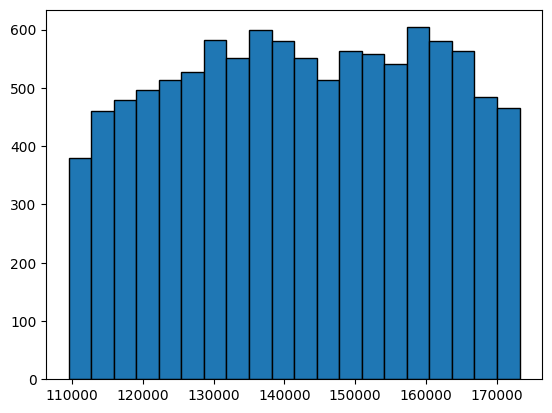

In [384]:
plt.hist(Data_Weight["Total_Weight"], bins=20, ec="k")
plt.show()

# Read the Data

In [385]:
Data = pd.read_csv("Data/Data_Train_Weight_Dep.csv")
Data.dropna(inplace=True)

In [386]:
Data.corr()["Total_Weight"].sort_values()

climb_angle_1    -0.718222
climb_angle_2    -0.673660
climb_angle_3    -0.670168
acc              -0.504150
wind_dir_cos_1   -0.042609
theta_1          -0.031543
theta_3          -0.031183
wind_speed_2     -0.030255
wind_dir_cos_3   -0.028360
wind_dir_cos_2   -0.025583
roll_2           -0.024107
wind_speed_3     -0.012414
wind_speed_1     -0.012405
wind_dir_sin_3   -0.012114
wind_dir_sin_2   -0.003823
roll_1            0.009660
wind_dir_sin_1    0.010178
roll_3            0.016686
theta_2           0.028635
Vg_3              0.039574
delta_1           0.075411
delta_3           0.076491
sigma_1           0.080673
sigma_3           0.081942
sigma_2           0.179237
delta_2           0.199072
Vg_1              0.560673
Vc_3              0.644756
Climb_CAS         0.955547
Vc_1              0.959743
Total_Weight      1.000000
Name: Total_Weight, dtype: float64

### Only Essentials

In [387]:
all_names = desired_columns
x_names = all_names[:-1]

In [388]:
# scaler = StandardScaler().fit(Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values)
# Data_scaled = pd.DataFrame(scaler.transform(Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values), index=Data.index, columns=Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].columns)
scaler = StandardScaler().fit(Data[all_names].values)
Data_scaled = pd.DataFrame(scaler.transform(Data[all_names].values), index=Data.index, columns=all_names)

In [395]:
# X_train, X_val, y_train, y_val = train_test_split(Data_scaled[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3"]], Data_scaled[['Total_Weight']], test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(Data_scaled[x_names], Data_scaled[['Total_Weight']], test_size=0.075)

In [396]:
X_train.shape

(9065, 29)

In [397]:
Data.describe()

,Vg_1,Vc_1,wind_speed_1,wind_dir_cos_1,wind_dir_sin_1,theta_1,sigma_1,delta_1,roll_1,climb_angle_1,...,wind_speed_3,wind_dir_cos_3,wind_dir_sin_3,theta_3,sigma_3,delta_3,roll_3,climb_angle_3,Total_Weight,Climb_CAS
count,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,...,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,151.488114,159.872369,16.212768,0.997598,0.016638,0.941392,0.918112,0.892716,-0.703689,10.355033,...,19.978311,0.940346,0.013994,0.888006,0.707557,0.649207,-0.004755,7.163817,142180.821854,160.969916
std,13.807269,8.272601,9.202887,0.008728,0.065030,0.038105,0.074779,0.064113,2.115389,3.492279,...,11.340253,0.205420,0.270858,0.031755,0.056098,0.046600,0.263601,1.664756,17724.846927,7.961015
min,109.537303,139.876582,0.002084,0.887665,-0.149577,0.876637,0.744251,0.772445,-10.313082,0.845097,...,0.002566,-0.962595,-0.686020,0.834051,0.578611,0.561960,-7.441655,3.791474,109507.586138,143.009032
25%,141.890413,153.269066,8.249874,0.999974,-0.004723,0.908402,0.860830,0.838428,-0.178936,7.863267,...,10.165940,0.976627,-0.141774,0.860507,0.663742,0.609653,-0.000735,5.907416,127446.665524,154.565089
50%,151.532097,160.771138,16.361885,0.999992,-0.002451,0.940147,0.917868,0.895762,-0.117705,9.887206,...,20.152849,0.992784,-0.028785,0.887016,0.708015,0.651394,-0.000210,6.849807,142316.192225,161.756755
75%,161.363851,166.669191,24.110772,0.999998,0.000051,0.973869,0.974101,0.948793,-0.065695,12.640629,...,29.713217,0.998447,0.087567,0.915073,0.750546,0.689960,0.000066,8.155982,157562.000967,167.421185
max,192.446290,177.875573,31.999081,1.000000,0.454715,1.009674,1.098652,0.999095,4.967521,23.200991,...,39.458507,1.000000,0.999999,0.944842,0.839692,0.726763,7.404628,24.380310,173252.067529,176.596833


# Create the Model

In [468]:
model = Sequential()
model_dropout = 0.0
model_activation = 'tanh'
batch_size = 32

model.add(Dense(16, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [469]:
model.summary()

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_61 (Dense)            (None, 16)                480       
                                                                 
 dropout_42 (Dropout)        (None, 16)                0         
                                                                 
 dense_62 (Dense)            (None, 16)                272       
                                                                 
 dropout_43 (Dropout)        (None, 16)                0         
                                                                 
 dense_63 (Dense)            (None, 1)                 17        
                                                                 
Total params: 769 (3.00 KB)
Trainable params: 769 (3.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Train the Model

## 1st LR

In [470]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [471]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
284/284 [==============================] - 1s 1ms/step - loss: 0.2464 - val_loss: 0.2367
Epoch 2/50
284/284 [==============================] - 0s 868us/step - loss: 0.1913 - val_loss: 0.1765
Epoch 3/50
284/284 [==============================] - 0s 849us/step - loss: 0.1524 - val_loss: 0.1256
Epoch 4/50
284/284 [==============================] - 0s 791us/step - loss: 0.1269 - val_loss: 0.1057
Epoch 5/50
284/284 [==============================] - 0s 809us/step - loss: 0.1190 - val_loss: 0.1079
Epoch 6/50
284/284 [==============================] - 0s 837us/step - loss: 0.1119 - val_loss: 0.1080
Epoch 7/50
284/284 [==============================] - 0s 810us/step - loss: 0.1120 - val_loss: 0.1249


In [472]:
losses = pd.DataFrame(model.history.history)

## 2nd LR

In [473]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [474]:
K.set_value(model.optimizer.learning_rate, 0.001)

In [475]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
284/284 [==============================] - 0s 950us/step - loss: 0.0856 - val_loss: 0.0795
Epoch 2/50
284/284 [==============================] - 0s 818us/step - loss: 0.0803 - val_loss: 0.0791
Epoch 3/50
284/284 [==============================] - 0s 868us/step - loss: 0.0795 - val_loss: 0.0777
Epoch 4/50
284/284 [==============================] - 0s 816us/step - loss: 0.0787 - val_loss: 0.0777
Epoch 5/50
284/284 [==============================] - 0s 795us/step - loss: 0.0782 - val_loss: 0.0770
Epoch 6/50
284/284 [==============================] - 0s 822us/step - loss: 0.0770 - val_loss: 0.0765
Epoch 7/50
284/284 [==============================] - 0s 803us/step - loss: 0.0765 - val_loss: 0.0800


In [476]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

# 3rd LR

In [477]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=1)

In [478]:
K.set_value(model.optimizer.learning_rate, 0.0001)

In [479]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
284/284 [==============================] - 0s 911us/step - loss: 0.0736 - val_loss: 0.0739
Epoch 2/50
284/284 [==============================] - 0s 822us/step - loss: 0.0730 - val_loss: 0.0738


In [480]:
predictions = model.predict(X_val)
mae_current = mean_absolute_error(y_val, predictions)
print("mae = ", mae_current*18000/170000*100)

23/23 [==============================] - 0s 647us/step
mae =  0.7815404230626911


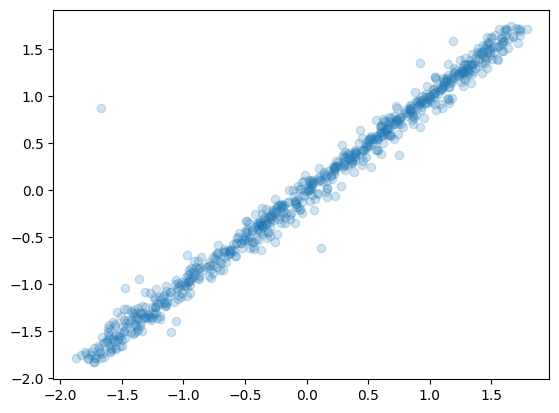

In [481]:
plt.scatter(predictions.flatten(), y_val, alpha=0.2)

<Axes: >

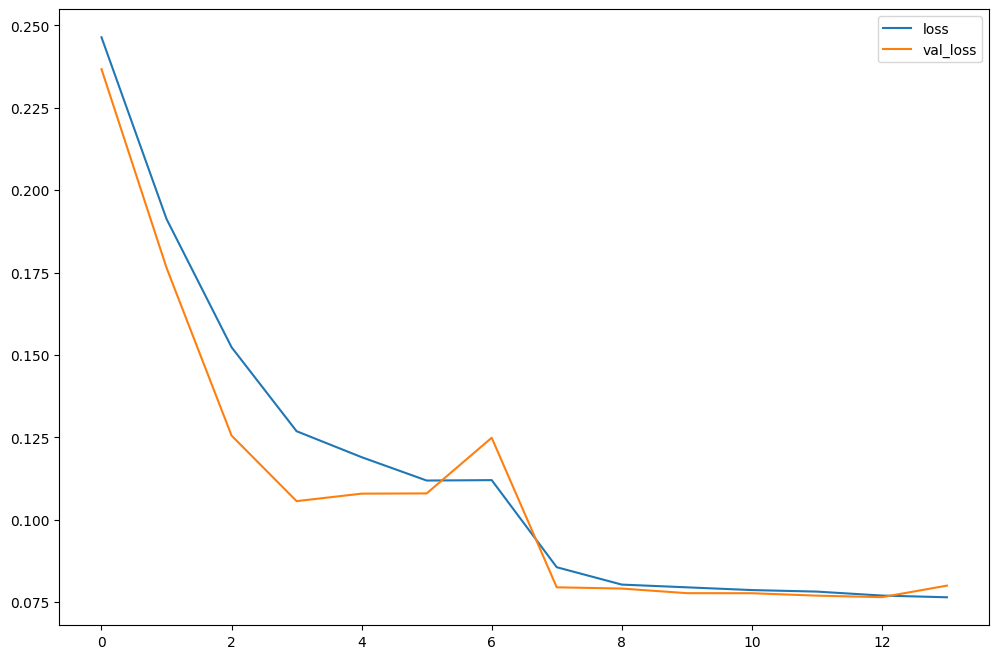

In [482]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))

# Test Score

In [483]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")
# Data_test = Data_test[Data_test["Altitude_Above_Ground"]>=0][["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]

In [484]:
Data_test.dropna(axis=0, inplace=True)

In [485]:
# Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values), index=Data_test.index, columns=Data_test[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].columns)
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[all_names].values), index=Data_test.index, columns=all_names)

In [486]:
X_test_scaled = Data_test_scaled[x_names]
y_test_scaled = Data_test_scaled[["Total_Weight"]]

In [487]:
y_pred_scaled = model.predict(X_test_scaled)

25/25 [==============================] - 0s 630us/step


In [488]:
mae_current = mean_absolute_error(y_test_scaled, y_pred_scaled)
print("mae = ", mae_current*18000/170000*100)

mae =  0.7909748324141957


In [489]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [490]:
print("r2 score for weight predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for weight predictions: %.5f" % (metrics.mean_absolute_error(Data_test["Total_Weight"], output[:,-1])))
print("MAE score for weight predictions as percentage: %.5f %%" % np.mean(100*np.abs(Data_test["Total_Weight"]-output[:,-1])*Data_test["Total_Weight"]**-1))
print("Maximum error for weight predictions: %.5f" % np.max(np.abs(Data_test["Total_Weight"]-output[:,-1])))

r2 score for weight predictions: 0.98966
MAE score for weight predictions: 1324.03485
MAE score for weight predictions as percentage: 0.95476 %
Maximum error for weight predictions: 12287.32624


In [491]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [458]:
Data_test[["Total_Weight"]].shape

(795, 1)

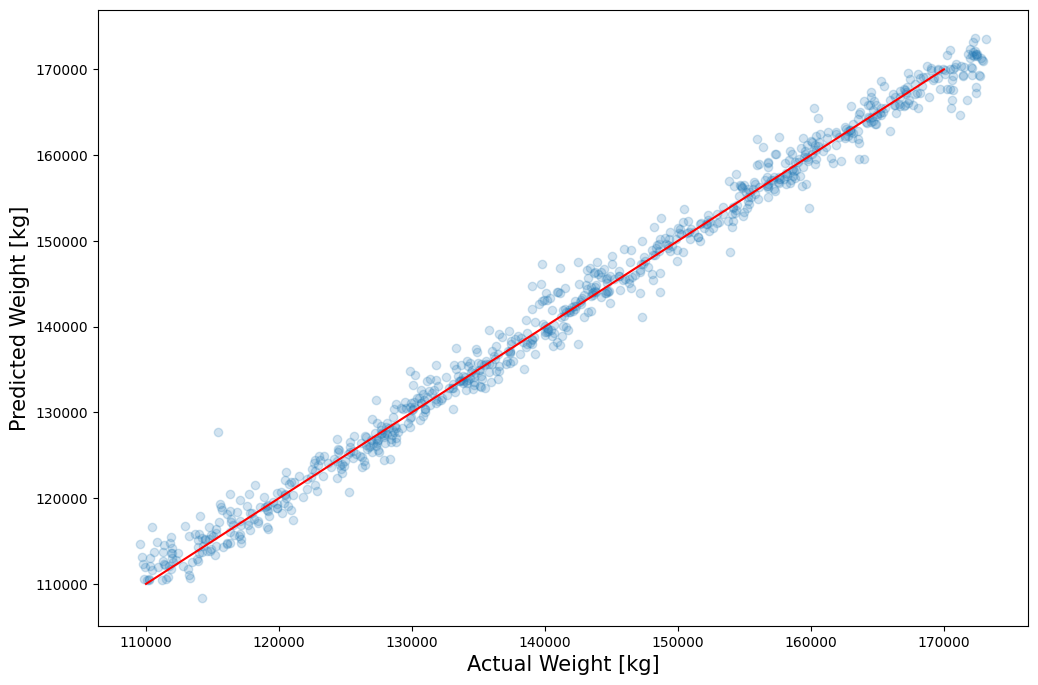

In [492]:
plt.figure(figsize=(12,8))
plt.scatter(Data_test[["Total_Weight"]], output[:,-1], alpha=0.2)
plt.ylabel("Predicted Weight [kg]", fontsize=15)
plt.xlabel("Actual Weight [kg]", fontsize=15)
plt.plot([110000, 170000], [110000, 170000], "r")
# plt.xlim([430000*0.453592, 690000*0.453592])
# plt.ylim([430000*0.453592, 690000*0.453592])
# plt.xticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.yticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_0.png", bbox_inches="tight", facecolor='white', transparent=False)

plt.show()

In [493]:
errors_lst = np.abs((output[:,-1] - Data_test["Total_Weight"].values)/Data_test["Total_Weight"])

In [494]:
np.mean(errors_lst[(Data_test["Total_Weight"]>120000) & (Data_test["Total_Weight"]<160000)])*100

0.9092553562817343

In [461]:
i_worst = np.argmax(np.abs(errors_lst))
Data_test.iloc[i_worst, :]

Vg_1                 124.166317
Vc_1                 149.670077
wind_speed_1          28.972773
wind_dir_cos_1         0.982492
wind_dir_sin_1         0.183393
theta_1                0.981262
sigma_1                0.977828
delta_1                0.992584
roll_1                -7.703941
climb_angle_1         18.235454
acc                    1.669361
wind_speed_2          33.234593
wind_dir_cos_2         0.330034
wind_dir_sin_2         0.943968
theta_2                0.935615
sigma_2                0.805666
delta_2                0.779781
roll_2                 0.083273
climb_angle_2          6.382084
Vg_3                 274.138063
Vc_3                 251.177746
wind_speed_3          35.717638
wind_dir_cos_3         0.408942
wind_dir_sin_3         0.912559
theta_3                0.921156
sigma_3                0.757199
delta_3                0.721558
roll_3                -0.225230
climb_angle_3         10.387849
Total_Weight      115437.830484
Climb_CAS            147.143460
Name: 24

In [426]:
output[i_worst, -1]

152830.80079020397

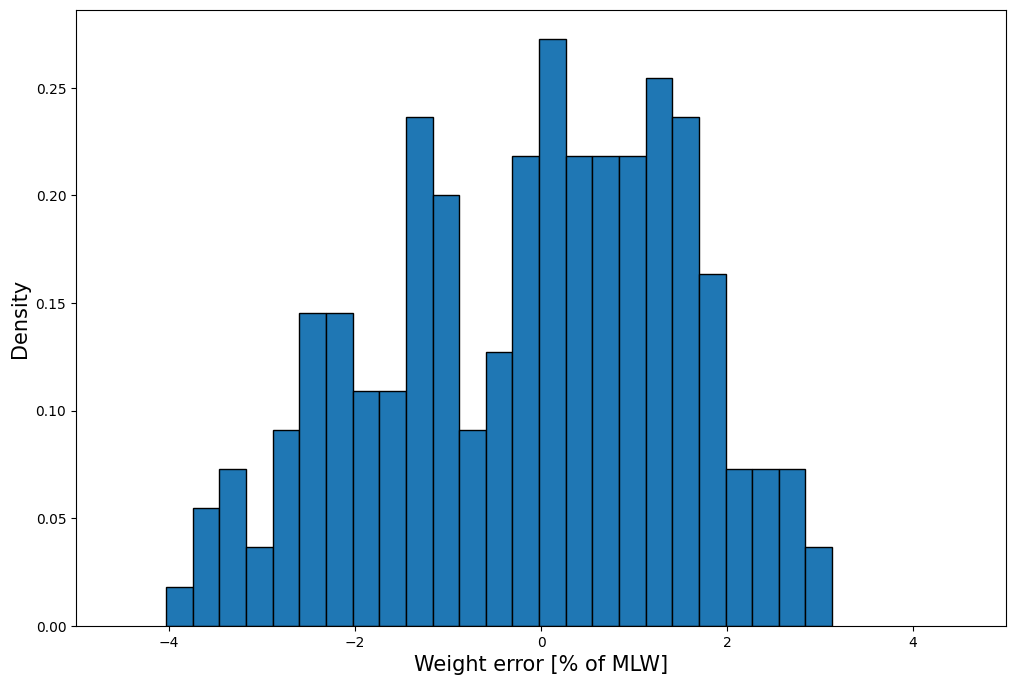

In [127]:
plt.figure(figsize=(12,8))
plt.hist(errors_lst, bins=25, ec="k", density=True)
plt.xlabel("Weight error [% of MLW]", fontsize=15)
plt.ylabel("Density", fontsize=15)
plt.xlim([-5,5])
plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_1.png", bbox_inches="tight", facecolor='white', transparent=False)

plt.show()

In [128]:
np.mean(np.abs(errors_lst))

1.3435959012220728

In [129]:
np.std(errors_lst)

1.619545521365912

# Save Model

In [130]:
model.save("E:\Work\Doing\Arrival Models\Models\model_weight")
dump(scaler, "E:\Work\Doing\Arrival Models\Models\model_weight\scaler.bin", compress=True)

INFO:tensorflow:Assets written to: E:\Work\Doing\Arrival Models\Models\model_weight\assets


INFO:tensorflow:Assets written to: E:\Work\Doing\Arrival Models\Models\model_weight\assets


['E:\\Work\\Doing\\Arrival Models\\Models\\model_weight\\scaler.bin']

In [8]:
model = keras.models.load_model("E://Models//model_weight")
scaler = load("E://Models//model_weight//scaler.bin")

# Predict Outputs for a Single Flight

In [9]:
def transform_angle(angle):
    if angle>180:
        angle -= 360
    return angle

# Score on an Old Dataset

In [1010]:
f_lst = []
d = r"E:\Stuff From Laptop\Polimi\Thesis\Stage 6 - Departure Data Generation Tests\747-400\Data\Old\8"
for (dirpath, dirnames, filenames) in os.walk(d):
    for f in filenames:
        f_lst.append(os.path.join(d,f))

In [1011]:
est_weight_lst = []
real_weight_lst = []
counter = 0
for f in f_lst[:]:
    df_temp = pd.DataFrame(columns=["Vg_1", "Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Vg_2", "Vc_2", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vg_3", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"])

    test_flight = pd.read_csv(f)
    real_weight_lst.append(np.mean(test_flight["Total_Weight"]))
    test_flight["theta"] = (test_flight["T_amb"] + 273.15)/298.15
    test_flight["Runway_Condition"] =test_flight.iloc[0]["Runway_Condition"]
    test_flight = test_flight[(test_flight["Distance"]>0) & (test_flight["Altitude_Above_Ground"]>=0)]
    test_flight.index = np.arange(len(test_flight))
    test_flight["Acceleration"] = 0
    for i in range(len(test_flight)):
        wind_dir = transform_angle(test_flight.loc[i, "Wind_Direction"]) - test_flight.loc[i, "Heading"]
        test_flight.loc[i, "Wind_dir_cos"] = np.cos(np.pi*wind_dir/180)
        test_flight.loc[i, "Wind_dir_sin"] = np.sin(np.pi*wind_dir/180)
        if i<(len(test_flight)-1):
            test_flight.loc[i, "Acceleration"] = (test_flight.loc[i+1, "Ground_Speed"] - test_flight.loc[i, "Ground_Speed"])/(test_flight.loc[i+1, "Time"] - test_flight.loc[i, "Time"])
    
    # --- Prepare Chunks of Data ---
    df_temp_1 = test_flight[(test_flight["Altitude_Above_Ground"]>100) & (test_flight["Altitude_Above_Ground"]<800)]
    mask = np.flatnonzero((test_flight["Acceleration"]>0.4) & (test_flight["Altitude_Above_Ground"]>500))
    df_temp_2 = test_flight.iloc[mask[0]+30:mask[0]+80]
    df_temp_3 = test_flight.iloc[-70:-20]
    
    # --- Fill in the Final Dataset ---
    df_temp.loc[counter, "Vg_1"] = np.mean(df_temp_1["Ground_Speed"])
    df_temp.loc[counter, "Vc_1"] = np.mean(df_temp_1["CAS"])
    df_temp.loc[counter, "Wind_Speed_1"] = np.mean(df_temp_1["Wind_Speed"])
    df_temp.loc[counter, "Wind_dir_cos_1"] = np.mean(df_temp_1["Wind_dir_cos"])
    df_temp.loc[counter, "Wind_dir_sin_1"] = np.mean(df_temp_1["Wind_dir_sin"])
    df_temp.loc[counter, "Acceleration_1"] = np.mean(df_temp_1["Acceleration"])
    df_temp.loc[counter, "theta_1"] = np.mean(df_temp_1["theta"])
    df_temp.loc[counter, "sigma_1"] = np.mean(df_temp_1["sigma"])
    df_temp.loc[counter, "delta_1"] = np.mean(df_temp_1["delta"])
    df_temp.loc[counter, "roll_1"] = np.mean(df_temp_1["Roll"])
    df_temp.loc[counter, "vpath_1"] = np.mean(df_temp_1["vpath"])
#     df_temp.loc[counter, "climb_angle_1"] = np.mean(df_temp_1["climb_angle"])
    
    
    df_temp.loc[counter, "Vg_2"] = np.mean(df_temp_2["Ground_Speed"])
    df_temp.loc[counter, "Vc_2"] = np.mean(df_temp_2["CAS"])
    df_temp.loc[counter, "Wind_Speed_2"] = np.mean(df_temp_2["Wind_Speed"])
    df_temp.loc[counter, "Wind_dir_cos_2"] = np.mean(df_temp_2["Wind_dir_cos"])
    df_temp.loc[counter, "Wind_dir_sin_2"] = np.mean(df_temp_2["Wind_dir_sin"])
    df_temp.loc[counter, "Acceleration_2"] = np.mean(df_temp_2["Acceleration"])
    df_temp.loc[counter, "theta_2"] = np.mean(df_temp_2["theta"])
    df_temp.loc[counter, "sigma_2"] = np.mean(df_temp_2["sigma"])
    df_temp.loc[counter, "delta_2"] = np.mean(df_temp_2["delta"])
    df_temp.loc[counter, "roll_2"] = np.mean(df_temp_2["Roll"])
    df_temp.loc[counter, "vpath_2"] = np.mean(df_temp_2["vpath"])
#     df_temp.loc[counter, "climb_angle_2"] = np.mean(df_temp_2["climb_angle"])
    
    
    df_temp.loc[counter, "Vg_3"] = np.mean(df_temp_3["Ground_Speed"])
    df_temp.loc[counter, "Vc_3"] = np.mean(df_temp_3["CAS"])
    df_temp.loc[counter, "Wind_Speed_3"] = np.mean(df_temp_3["Wind_Speed"])
    df_temp.loc[counter, "Wind_dir_cos_3"] = np.mean(df_temp_3["Wind_dir_cos"])
    df_temp.loc[counter, "Wind_dir_sin_3"] = np.mean(df_temp_3["Wind_dir_sin"])
    df_temp.loc[counter, "Acceleration_3"] = np.mean(df_temp_3["Acceleration"])
    df_temp.loc[counter, "theta_3"] = np.mean(df_temp_3["theta"])
    df_temp.loc[counter, "sigma_3"] = np.mean(df_temp_3["sigma"])
    df_temp.loc[counter, "delta_3"] = np.mean(df_temp_3["delta"])
    df_temp.loc[counter, "roll_3"] = 0
    df_temp.loc[counter, "vpath_3"] = np.mean(df_temp_3["vpath"])
#     df_temp.loc[counter, "climb_angle_3"] = np.mean(df_temp_3["climb_angle"])
    
    df_temp.loc[counter, "Total_Weight"] = np.mean(test_flight["Total_Weight"])
    
    flight_data_scaled = pd.DataFrame(scaler.transform(df_temp.values), index=df_temp.index, columns=df_temp.columns)
    X_flight = flight_data_scaled[["Vg_1", "Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Vg_2", "Vc_2", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vg_3", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3"]]
    y_pred_scaled = model.predict(X_flight.values.reshape([1,X_flight.shape[1]]).astype(float))
    
    output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
#     y_pred = output[-1]
    
    est_weight_lst.append(output[0][-1])
    
    counter += 1


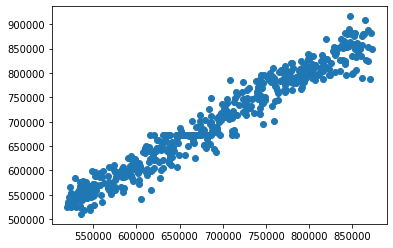

In [1012]:
plt.scatter(real_weight_lst, est_weight_lst)
plt.show()

In [1013]:
np.mean(np.abs(np.array(est_weight_lst)-np.array(real_weight_lst)))

19505.735654219105

In [999]:
f = f_lst[np.argmax(np.abs(np.array(est_weight_lst)-np.array(real_weight_lst)))]
df_temp = pd.DataFrame(columns=["Vg_1", "Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Vg_2", "Vc_2", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vg_3", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"])

test_flight = pd.read_csv(f)
# real_weight_lst.append(np.mean(test_flight["Total_Weight"]))
test_flight["theta"] = (test_flight["T_amb"] + 273.15)/298.15
test_flight["Runway_Condition"] =test_flight.iloc[0]["Runway_Condition"]
test_flight = test_flight[(test_flight["Distance"]>0) & (test_flight["Altitude_Above_Ground"]>=0)]
test_flight.index = np.arange(len(test_flight))
test_flight["Acceleration"] = 0
for i in range(len(test_flight)):
    wind_dir = transform_angle(test_flight.loc[i, "Wind_Direction"]) - test_flight.loc[i, "Heading"]
    test_flight.loc[i, "Wind_dir_cos"] = np.cos(np.pi*wind_dir/180)
    test_flight.loc[i, "Wind_dir_sin"] = np.sin(np.pi*wind_dir/180)
    if i<(len(test_flight)-1):
        test_flight.loc[i, "Acceleration"] = (test_flight.loc[i+1, "Ground_Speed"] - test_flight.loc[i, "Ground_Speed"])/(test_flight.loc[i+1, "Time"] - test_flight.loc[i, "Time"])

# --- Prepare Chunks of Data ---
df_temp_1 = test_flight[(test_flight["Altitude_Above_Ground"]>100) & (test_flight["Altitude_Above_Ground"]<800)]
mask = np.flatnonzero((test_flight["Acceleration"]>0.4) & (test_flight["Altitude_Above_Ground"]>500))
df_temp_2 = test_flight.iloc[mask[0]+30:mask[0]+80]
df_temp_3 = test_flight.iloc[-70:-20]

# --- Fill in the Final Dataset ---
df_temp.loc[counter, "Vg_1"] = np.mean(df_temp_1["Ground_Speed"])
df_temp.loc[counter, "Vc_1"] = np.mean(df_temp_1["CAS"])
df_temp.loc[counter, "Wind_Speed_1"] = np.mean(df_temp_1["Wind_Speed"])
df_temp.loc[counter, "Wind_dir_cos_1"] = np.mean(df_temp_1["Wind_dir_cos"])
df_temp.loc[counter, "Wind_dir_sin_1"] = np.mean(df_temp_1["Wind_dir_sin"])
df_temp.loc[counter, "Acceleration_1"] = np.mean(df_temp_1["Acceleration"])
df_temp.loc[counter, "theta_1"] = np.mean(df_temp_1["theta"])
df_temp.loc[counter, "sigma_1"] = np.mean(df_temp_1["sigma"])
df_temp.loc[counter, "delta_1"] = np.mean(df_temp_1["delta"])
df_temp.loc[counter, "roll_1"] = np.mean(df_temp_1["Roll"])
df_temp.loc[counter, "vpath_1"] = np.mean(df_temp_1["vpath"])
#     df_temp.loc[counter, "climb_angle_1"] = np.mean(df_temp_1["climb_angle"])


df_temp.loc[counter, "Vg_2"] = np.mean(df_temp_2["Ground_Speed"])
df_temp.loc[counter, "Vc_2"] = np.mean(df_temp_2["CAS"])
df_temp.loc[counter, "Wind_Speed_2"] = np.mean(df_temp_2["Wind_Speed"])
df_temp.loc[counter, "Wind_dir_cos_2"] = np.mean(df_temp_2["Wind_dir_cos"])
df_temp.loc[counter, "Wind_dir_sin_2"] = np.mean(df_temp_2["Wind_dir_sin"])
df_temp.loc[counter, "Acceleration_2"] = np.mean(df_temp_2["Acceleration"])
df_temp.loc[counter, "theta_2"] = np.mean(df_temp_2["theta"])
df_temp.loc[counter, "sigma_2"] = np.mean(df_temp_2["sigma"])
df_temp.loc[counter, "delta_2"] = np.mean(df_temp_2["delta"])
df_temp.loc[counter, "roll_2"] = np.mean(df_temp_2["Roll"])
df_temp.loc[counter, "vpath_2"] = np.mean(df_temp_2["vpath"])
#     df_temp.loc[counter, "climb_angle_2"] = np.mean(df_temp_2["climb_angle"])


df_temp.loc[counter, "Vg_3"] = np.mean(df_temp_3["Ground_Speed"])
df_temp.loc[counter, "Vc_3"] = np.mean(df_temp_3["CAS"])
df_temp.loc[counter, "Wind_Speed_3"] = np.mean(df_temp_3["Wind_Speed"])
df_temp.loc[counter, "Wind_dir_cos_3"] = np.mean(df_temp_3["Wind_dir_cos"])
df_temp.loc[counter, "Wind_dir_sin_3"] = np.mean(df_temp_3["Wind_dir_sin"])
df_temp.loc[counter, "Acceleration_3"] = np.mean(df_temp_3["Acceleration"])
df_temp.loc[counter, "theta_3"] = np.mean(df_temp_3["theta"])
df_temp.loc[counter, "sigma_3"] = np.mean(df_temp_3["sigma"])
df_temp.loc[counter, "delta_3"] = np.mean(df_temp_3["delta"])
df_temp.loc[counter, "roll_3"] = np.mean(df_temp_3["Roll"])
df_temp.loc[counter, "vpath_3"] = np.mean(df_temp_3["vpath"])
#     df_temp.loc[counter, "climb_angle_3"] = np.mean(df_temp_3["climb_angle"])

df_temp.loc[counter, "Total_Weight"] = np.mean(test_flight["Total_Weight"])

flight_data_scaled = pd.DataFrame(scaler.transform(df_temp.values), index=df_temp.index, columns=df_temp.columns)
X_flight = flight_data_scaled[["Vg_1", "Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Vg_2", "Vc_2", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vg_3", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3"]]
y_pred_scaled = model.predict(X_flight.values.reshape([1,X_flight.shape[1]]).astype(float))

output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
#     y_pred = output[-1]
    

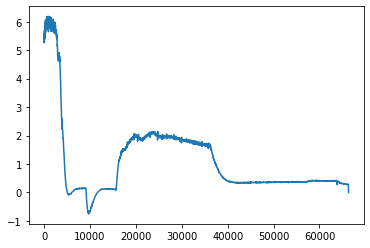

In [1001]:
plt.plot(test_flight["Distance"], test_flight["Acceleration"])

In [1002]:
X_flight

,Vg_1,Vc_1,Wind_Speed_1,Wind_dir_cos_1,Wind_dir_sin_1,Acceleration_1,theta_1,sigma_1,delta_1,roll_1,...,Vc_3,Wind_Speed_3,Wind_dir_cos_3,Wind_dir_sin_3,Acceleration_3,theta_3,sigma_3,delta_3,roll_3,vpath_3
100,0.7194,0.631896,0.060862,0.265787,0.860647,3.089265,1.666872,-0.953671,1.083891,-0.526747,...,0.942622,0.064147,-0.678481,1.525312,4.966019,1.690162,-0.792299,1.238954,-184.932056,3.123962


In [1003]:
df_temp["roll_3"]

100   -4.702858
Name: roll_3, dtype: object

# Score on a New Dataset

In [158]:
f_lst = []
d = r"E:\Stuff From Laptop\Polimi\Thesis\Stage 6 - Departure Data Generation Tests\747-400\Data\New\Test\13"
for (dirpath, dirnames, filenames) in os.walk(d):
    for f in filenames:
        f_lst.append(os.path.join(d,f))

In [159]:
mae_lst= []
weight_lst = []
for f in f_lst[:100]:
    test_flight = pd.read_csv(f)
    weight_lst.append(np.mean(test_flight["Total_Weight"]))
#     test_flight["theta"] = (test_flight["T_amb"] + 273.15)/298.15
    test_flight["Runway_Condition"] =test_flight.iloc[0]["Runway_Condition"]
#     test_flight = test_flight[(test_flight["Distance"]>0) & (test_flight["Altitude_Above_Ground"]>=0)]
    test_flight.index = np.arange(len(test_flight))
    test_flight["Acceleration"] = 0
    for i in range(len(test_flight)):
        wind_dir = transform_angle(test_flight.loc[i, "Wind_Direction"]) - test_flight.loc[i, "Heading"]
        test_flight.loc[i, "Wind_dir_cos"] = np.cos(np.pi*wind_dir/180)
        test_flight.loc[i, "Wind_dir_sin"] = np.sin(np.pi*wind_dir/180)
        if i<(len(test_flight)-1):
            test_flight.loc[i, "Acceleration"] = (test_flight.loc[i+1, "Ground_Speed"] - test_flight.loc[i, "Ground_Speed"])/(test_flight.loc[i+1, "Time"] - test_flight.loc[i, "Time"])
    
    flight_data = test_flight[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
    flight_data_scaled = pd.DataFrame(scaler.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
    X_flight = flight_data_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight"]]
    
    start_time = time.time()
    y_pred_scaled = model.predict(X_flight)
    output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
    y_pred = output[:,-1]
    
    mae_lst.append(metrics.mean_absolute_error(flight_data["Thrust"], y_pred))

In [160]:
print("Minimum MAE: %.5f" % min(mae_lst))
print("Maximum MAE: %.5f" % max(mae_lst))
print("Average MAE: %.5f" % (sum(mae_lst)/len(mae_lst)))

Minimum MAE: 152.55415
Maximum MAE: 1519.41126
Average MAE: 432.32623


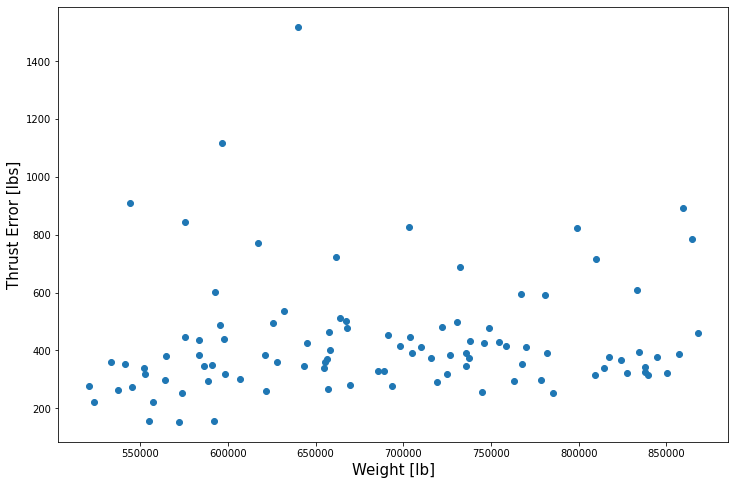

In [161]:
plt.figure(figsize=(12,8))
plt.scatter(weight_lst, mae_lst)
plt.xlabel("Weight [lb]", fontsize=15)
plt.ylabel("Thrust Error [lbs]", fontsize=15)
plt.show()

# ADSB  Replica

## Calculating Distance

In [20]:
def haversine(theta):
    return math.sin(theta/2)**2

def great_arc(lon1,lat1,lon2,lat2):
    lon1 *= math.pi/180
    lat1 *= math.pi/180
    lon2 *= math.pi/180
    lat2 *= math.pi/180
    return 2*math.asin(math.sqrt(haversine(lat2-lat1)+math.cos(lat1)*math.cos(lat2)*haversine(lon2-lon1)))

def earth_radius(lat):
    """
    Calculates the earth radius [km] at the given latitude [deg] 
    """
    lat *= math.pi/180
    a = 6378.137*3280.84  # Radius at sea level at equator [feet]
    b = 6356.752*3280.84  # Radius at poles [feet]
    c = (a**2*math.cos(lat))**2
    d = (b**2*math.sin(lat))**2
    e = (a*math.cos(lat))**2
    f = (b*math.sin(lat))**2
    return math.sqrt((c+d)/(e+f))

def get_distance(lon1,lat1,lon2,lat2):
    """
    Calculates the distance [km] between two points on the great circle, ...
    ... using their respective longitude [deg] and latitude [deg]
    """
    R = (earth_radius(lat1) + earth_radius(lat2))/2
    return R*great_arc(lon1,lat1,lon2,lat2)

## Main

In [21]:
def replicate_ADSB(input_df):
    output_df_accurate = pd.DataFrame(columns=test_flight.columns)
    output_df_ADSB = pd.DataFrame(columns=test_flight.columns)
    counter = 0
    dt_temp = 5 + np.random.lognormal(mean=0, sigma=1)
    dt_prev = copy.copy(dt_temp)
    t_prev = input_df.iloc[0]["Time"]
    output_df_accurate.loc[counter,:] = input_df.iloc[0]
    output_df_ADSB.loc[counter,:] = input_df.iloc[0]
    output_df_ADSB.loc[counter, "Acceleration"] = 0
    output_df_ADSB.loc[counter, "Roll"] = 0
    lat_prev = input_df.iloc[0]["Latitude"]
    lon_prev = input_df.iloc[0]["Longitude"]
    check_dt = 0
    for i in range(len(input_df)):
        if check_dt:
            dt_temp = 5 + np.random.lognormal(mean=0, sigma=1)
        if (input_df.iloc[i]["Time"]-t_prev)>dt_temp:
            t_prev = input_df.iloc[i]["Time"]
            check_dt = 1
            counter += 1
            output_df_accurate.loc[counter,:] = input_df.iloc[i]
            output_df_ADSB.loc[counter,:] = input_df.iloc[i]
            if counter==1:
                lat_temp = input_df.iloc[i]["Latitude"]
                lon_temp = input_df.iloc[i]["Longitude"]
                d_prev = get_distance(lon_temp,lat_temp,lon_prev,lat_prev)
                d_vec_prev = [lon_temp-lon_prev,lat_temp-lat_prev,0]
                lon_prev = copy.copy(lon_temp)
                lat_prev = copy.copy(lat_temp)
                output_df_ADSB.loc[counter-1, "Acceleration"] = (output_df_ADSB.loc[counter, "Ground_Speed"] - output_df_ADSB.loc[counter-1, "Ground_Speed"])/(output_df_ADSB.loc[counter, "Time"] - output_df_ADSB.loc[counter-1, "Time"])
                output_df_ADSB.loc[counter, "Acceleration"] = (output_df_ADSB.loc[counter, "Ground_Speed"] - output_df_ADSB.loc[counter-1, "Ground_Speed"])/(output_df_ADSB.loc[counter, "Time"] - output_df_ADSB.loc[counter-1, "Time"])
                
            else:
                lat_temp = input_df.iloc[i]["Latitude"]
                lon_temp = input_df.iloc[i]["Longitude"]
                d_temp = get_distance(lon_temp,lat_temp,lon_prev,lat_prev)
                d_vec_temp = [lon_temp-lon_prev,lat_temp-lat_prev,0]
                th = np.arccos(np.dot(d_vec_prev,d_vec_temp)/(np.linalg.norm(d_vec_temp)*np.linalg.norm(d_vec_prev)))
                y_d = np.tan(th/2)
                y_dd = 2*np.tan(th)/(d_temp + d_prev)
                k = y_dd/(1+y_d**2)**1.5
                output_df_ADSB.loc[counter-1, "Roll"] = np.sign(np.cross(d_vec_temp, d_vec_prev)[2])*180*np.arctan(2.85*k*output_df_ADSB.loc[counter-1, "Ground_Speed"]**2/9.81*0.3048)/np.pi
                output_df_ADSB.loc[counter, "Acceleration"] = (output_df_ADSB.loc[counter, "Ground_Speed"] - output_df_ADSB.loc[counter-1, "Ground_Speed"])/(output_df_ADSB.loc[counter, "Time"] - output_df_ADSB.loc[counter-1, "Time"])
                output_df_ADSB.loc[counter-1, "Acceleration"] = (output_df_ADSB.loc[counter-1, "Acceleration"] + output_df_ADSB.loc[counter, "Acceleration"])/2
                lat_prev = copy.copy(lat_temp)
                lon_prev = copy.copy(lon_temp)
                d_prev = copy.copy(d_temp)
                d_vec_prev = copy.copy(d_vec_temp)
            dt_prev = copy.copy(dt_temp)
    output_df_ADSB.loc[counter, "Roll"] = output_df_ADSB.loc[counter-1, "Roll"]
    
    for i in range(len(output_df_ADSB)):
        try:
            if i==0:
                output_df_ADSB.loc[i, "vpath"] = np.arctan((output_df_ADSB.loc[i+1,"Altitude_Above_Ground"]-output_df_ADSB.loc[i,"Altitude_Above_Ground"])/(output_df_ADSB.loc[i+1,"Distance"]-output_df_ADSB.loc[i,"Distance"]))*180/np.pi
            elif i==len(output_df_ADSB)-1:
                output_df_ADSB.loc[i, "vpath"] = np.arctan((output_df_ADSB.loc[i,"Altitude_Above_Ground"]-output_df_ADSB.loc[i-1,"Altitude_Above_Ground"])/(output_df_ADSB.loc[i,"Distance"]-output_df_ADSB.loc[i-1,"Distance"]))*180/np.pi
            else:
                output_df_ADSB.loc[i, "vpath"] = np.arctan((output_df_ADSB.loc[i+1,"Altitude_Above_Ground"]-output_df_ADSB.loc[i-1,"Altitude_Above_Ground"])/(output_df_ADSB.loc[i+1,"Distance"]-output_df_ADSB.loc[i-1,"Distance"]))*180/np.pi
        except:
            output_df_ADSB.loc[i, "vpath"] = 0
    return output_df_accurate, output_df_ADSB

## Score Comparison with ADSB

In [25]:
f_lst = []
d = r"E:\Stuff From Laptop\Polimi\Thesis\Stage 6 - Departure Data Generation Tests\747-400\Data\New\Test\13"
for (dirpath, dirnames, filenames) in os.walk(d):
    for f in filenames:
        f_lst.append(os.path.join(d,f))

In [26]:
mae_lst_accurate= []
r2_lst_accurate = []
mae_lst_ADSB = []
r2_lst_ADSB = []
weight_lst = []
for f in f_lst[:100]:
#     print(f)
    test_flight = pd.read_csv(f)
    weight_lst.append(np.mean(test_flight["Total_Weight"]))
#     test_flight["theta"] = (test_flight["T_amb"] + 273.15)/298.15
    test_flight["Runway_Condition"] =test_flight.iloc[0]["Runway_Condition"]
    test_flight = test_flight[(test_flight["Distance"]>0) & (test_flight["Altitude_Above_Ground"]>=0)]
    test_flight.reset_index(inplace=True, drop=True)
    test_flight["Acceleration"] = 0
    for i in range(len(test_flight)):
        wind_dir = transform_angle(test_flight.loc[i, "Wind_Direction"]) - test_flight.loc[i, "Heading"]
        test_flight.loc[i, "Wind_dir_cos"] = np.cos(np.pi*wind_dir/180)
        test_flight.loc[i, "Wind_dir_sin"] = np.sin(np.pi*wind_dir/180)
        if i<(len(test_flight)-1):
            test_flight.loc[i, "Acceleration"] = (test_flight.loc[i+1, "Ground_Speed"] - test_flight.loc[i, "Ground_Speed"])/(test_flight.loc[i+1, "Time"] - test_flight.loc[i, "Time"])
    # Get the ADSB replica
    test_flight_accurate, test_flight_ADSB = replicate_ADSB(test_flight)
    
    # Accurate data predictions
    flight_data = test_flight_accurate[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
    flight_data_scaled = pd.DataFrame(scaler.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
    X_flight = flight_data_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight"]]
    
    start_time = time.time()
    y_pred_scaled = model.predict(X_flight)
    output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
    y_pred = output[:,-1]
    
    mae_lst_accurate.append(metrics.mean_absolute_error(flight_data["Thrust"], y_pred))
    r2_lst_accurate.append(metrics.r2_score(flight_data["Thrust"], y_pred))
    
    # ADSB data predictions
    flight_data = test_flight_ADSB[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
    flight_data_scaled = pd.DataFrame(scaler.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
    X_flight = flight_data_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight"]]
    
    start_time = time.time()
    y_pred_scaled = model.predict(X_flight)
    output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
    y_pred = output[:,-1]
    
    mae_lst_ADSB.append(metrics.mean_absolute_error(flight_data["Thrust"], y_pred))
    r2_lst_ADSB.append(metrics.r2_score(flight_data["Thrust"], y_pred))

In [27]:
print("Accurate Data Scores:")
print("\t Minimum MAE: %.5f" % min(mae_lst_accurate))
print("\t Maximum MAE: %.5f" % max(mae_lst_accurate))
print("\t Average MAE: %.5f" % (sum(mae_lst_accurate)/len(mae_lst_accurate)))
print("\t Average R2 Score: %.5f" % (np.mean(r2_lst_accurate)))

print("ADSB Data Scores:")
print("\t Minimum MAE: %.5f" % min(mae_lst_ADSB))
print("\t Maximum MAE: %.5f" % max(mae_lst_ADSB))
print("\t Average MAE: %.5f" % (sum(mae_lst_ADSB)/len(mae_lst_ADSB)))
print("\t Average R2 Score: %.5f" % (np.mean(r2_lst_ADSB)))

Accurate Data Scores:
	 Minimum MAE: 100.10775
	 Maximum MAE: 1567.34626
	 Average MAE: 408.49202
	 Average R2 Score: 0.98042
ADSB Data Scores:
	 Minimum MAE: 490.84571
	 Maximum MAE: 5964.62883
	 Average MAE: 2183.59968
	 Average R2 Score: 0.64586


# ADSB on Single Flight

In [28]:
def transform_angle(angle):
    if angle>180:
        angle -= 360
    return angle

In [29]:
Directory = f_lst[np.argmax(mae_lst_ADSB)]
test_flight = pd.read_csv(Directory)
# test_flight = pd.read_csv(r"E:\Stuff From Laptop\Polimi\Thesis\Stage 6 - Departure Data Generation\747-400\Data\10\2022-07-01---15-10-43.csv")
# test_flight["theta"] = (test_flight["T_amb"] + 273.15)/298.15
test_flight["Runway_Condition"] = test_flight.iloc[0]["Runway_Condition"]
test_flight["Acceleration"] = 0
for i in range(len(test_flight)):
    wind_dir = transform_angle(test_flight.loc[i, "Wind_Direction"]) - test_flight.loc[i, "Heading"]
    test_flight.loc[i, "Wind_dir_cos"] = np.cos(np.pi*wind_dir/180)
    test_flight.loc[i, "Wind_dir_sin"] = np.sin(np.pi*wind_dir/180)
    if i<(len(test_flight)-1):
        test_flight.loc[i, "Acceleration"] = (test_flight.loc[i+1, "Ground_Speed"] - test_flight.loc[i, "Ground_Speed"])/(test_flight.loc[i+1, "Time"] - test_flight.loc[i, "Time"])


In [30]:
test_flight_accurate, test_flight_ADSB = replicate_ADSB(test_flight)

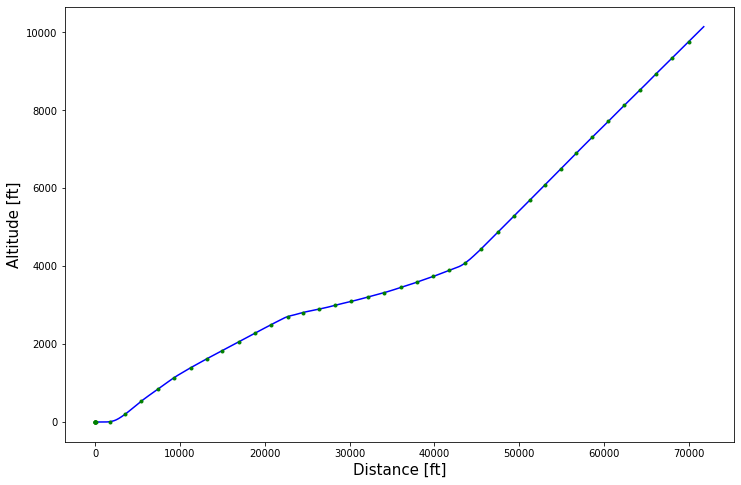

In [31]:
plt.figure(figsize=(12,8))
plt.plot(test_flight["Distance"], test_flight["Altitude_Above_Ground"], "b")
plt.plot(test_flight_ADSB["Distance"], test_flight_ADSB["Altitude_Above_Ground"], ".g")
plt.xlabel("Distance [ft]", fontsize=15)
plt.ylabel("Altitude [ft]", fontsize=15)
plt.show()

In [44]:
alpha = 0.7
for i in range(len(test_flight)):
    if i==0:
        test_flight.loc[i, "Acceleration_2"] = test_flight.loc[i, "Acceleration"]
    else:
        test_flight.loc[i, "Acceleration_2"] = alpha*test_flight.loc[i-1, "Acceleration_2"] + (1-alpha)*test_flight.loc[i, "Acceleration"]

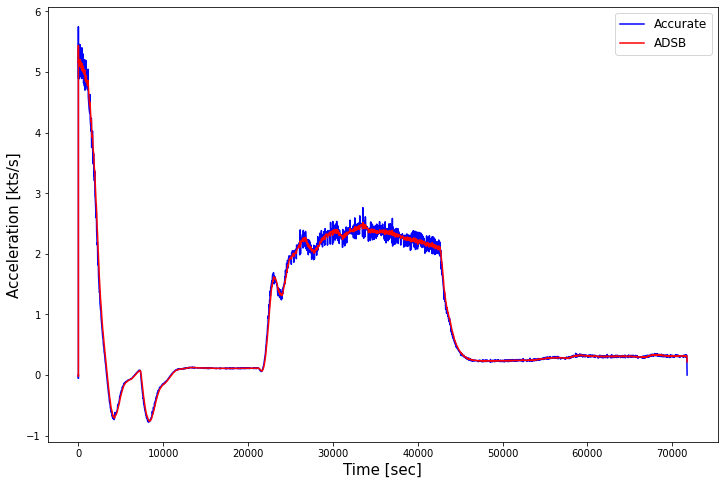

In [45]:
plt.figure(figsize=(12,8))
plt.plot(test_flight["Distance"], test_flight["Acceleration"], "b")
plt.plot(test_flight["Distance"], test_flight["Acceleration_2"], "r")
plt.xlabel("Time [sec]", fontsize=15)
plt.ylabel("Acceleration [kts/s]", fontsize=15)
plt.legend(["Accurate", "ADSB"], fontsize=12)
plt.show()

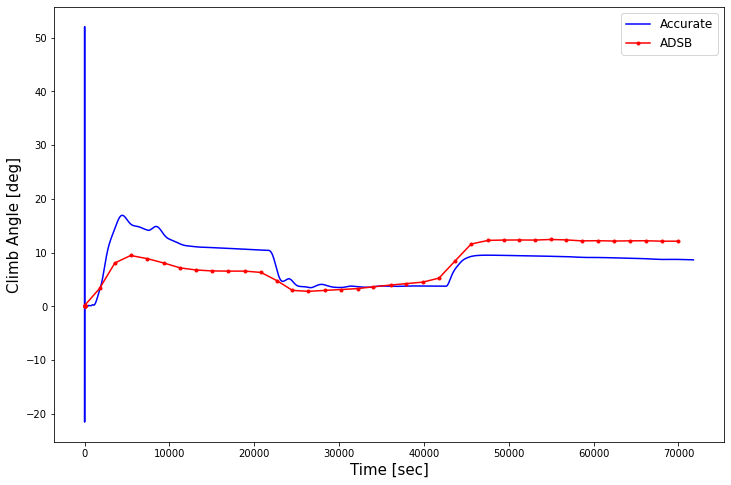

In [33]:
plt.figure(figsize=(12,8))
plt.plot(test_flight["Distance"], test_flight["vpath"], "b")
plt.plot(test_flight_ADSB["Distance"], test_flight_ADSB["vpath"], ".-r")
plt.xlabel("Time [sec]", fontsize=15)
plt.ylabel("Climb Angle [deg]", fontsize=15)
plt.legend(["Accurate", "ADSB"], fontsize=12)
plt.show()

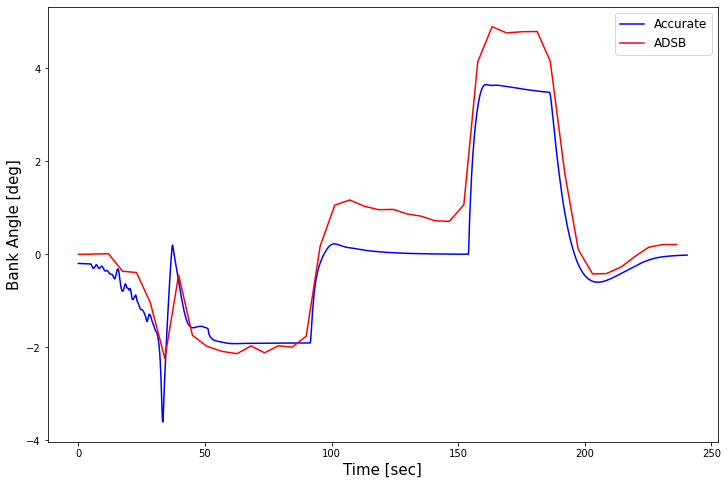

In [172]:
plt.figure(figsize=(12,8))
plt.plot(test_flight["Time"], test_flight["Roll"], "b")
plt.plot(test_flight_ADSB["Time"], test_flight_ADSB["Roll"], "r")
plt.xlabel("Time [sec]", fontsize=15)
plt.ylabel("Bank Angle [deg]", fontsize=15)
plt.legend(["Accurate", "ADSB"], fontsize=12)
plt.show()

In [35]:
test_flight_accurate = copy.copy(test_flight)
for i in range(len(test_flight_accurate)):
    try:
        if i==0:
            test_flight_accurate.loc[i, "vpath"] = np.arctan((test_flight_accurate.loc[i+1,"Altitude_Above_Ground"]-test_flight_accurate.loc[i,"Altitude_Above_Ground"])/(test_flight_accurate.loc[i+1,"Distance"]-test_flight_accurate.loc[i,"Distance"]))*180/np.pi
        elif i==len(test_flight_accurate)-1:
            test_flight_accurate.loc[i, "vpath"] = np.arctan((test_flight_accurate.loc[i,"Altitude_Above_Ground"]-test_flight_accurate.loc[i-1,"Altitude_Above_Ground"])/(test_flight_accurate.loc[i,"Distance"]-test_flight_accurate.loc[i-1,"Distance"]))*180/np.pi
        else:
            test_flight_accurate.loc[i, "vpath"] = np.arctan((test_flight_accurate.loc[i+1,"Altitude_Above_Ground"]-test_flight_accurate.loc[i-1,"Altitude_Above_Ground"])/(test_flight_accurate.loc[i+1,"Distance"]-test_flight_accurate.loc[i-1,"Distance"]))*180/np.pi
    except:
        test_flight_accurate.loc[i, "vpath"] = 0

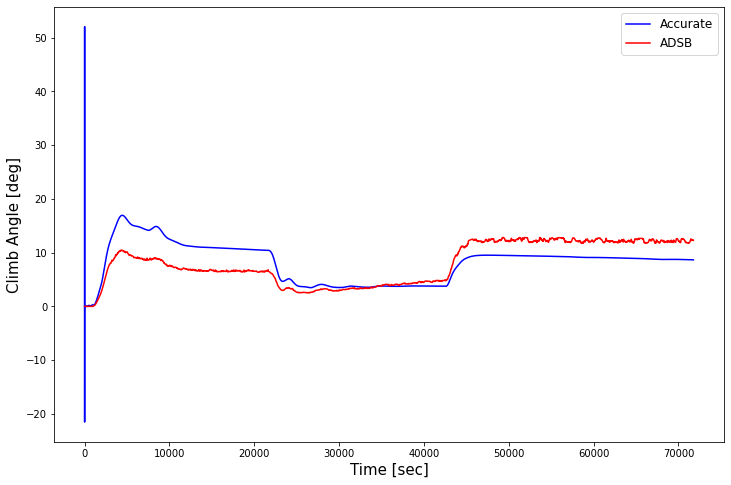

In [36]:
plt.figure(figsize=(12,8))
plt.plot(test_flight["Distance"], test_flight["vpath"], "b")
plt.plot(test_flight_accurate["Distance"], test_flight_accurate["vpath"], "-r")
plt.xlabel("Time [sec]", fontsize=15)
plt.ylabel("Climb Angle [deg]", fontsize=15)
plt.legend(["Accurate", "ADSB"], fontsize=12)
plt.show()

In [173]:
# Accurate Predictions
flight_data = test_flight[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
# flight_data["Total_Weight"] = flight_data["Total_Weight"] - 20000
flight_data_scaled = pd.DataFrame(scaler.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight"]]

y_pred_scaled = model.predict(X_flight)
output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred = output[:,-1]

# ADSB Predictions
flight_data = test_flight_ADSB[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
# flight_data["Total_Weight"] = flight_data["Total_Weight"] - 20000
flight_data_scaled = pd.DataFrame(scaler.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight"]]

time_adsb = test_flight_ADSB["Time"]
y_pred_scaled = model.predict(X_flight)
output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred_ADSB = output[:,-1]

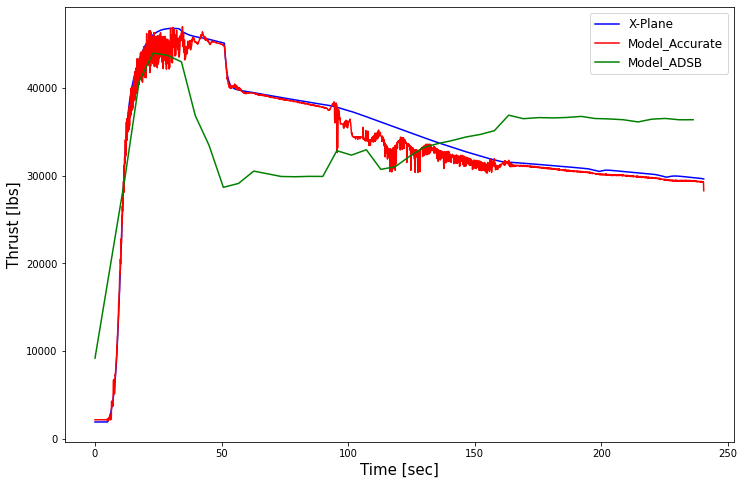

In [174]:
plt.figure(figsize=[12,8])
plt.plot(test_flight["Time"], test_flight["Thrust"], "b")
plt.plot(test_flight["Time"], y_pred, "r")
plt.plot(time_adsb, y_pred_ADSB, "g")
plt.xlabel("Time [sec]", fontsize=15)
plt.ylabel("Thrust [lbs]", fontsize=15)
plt.legend(["X-Plane", "Model_Accurate", "Model_ADSB"], fontsize=12)
plt.show()

In [186]:
y_pred_ADSB.shape

(46,)

In [187]:
x_adsb.shape

(47,)

# Climb Angle Model

In [76]:
X_train = Data_train_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight","Thrust"]]
y_train = Data_train_scaled[['vpath']]

In [77]:
X_val = Data_val_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight","Thrust"]]
y_val = Data_val_scaled[['vpath']]

## Create the Model

In [78]:
model = Sequential()
model_dropout = 0.0
model_activation = 'sigmoid'
batch_size = 256

model.add(Dense(64, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(64, activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(32, activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

## 1st LR

In [79]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [80]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
133933/133933 [==============================] - 115s 837us/step - loss: 0.0443 - val_loss: 0.0391
Epoch 2/50
133933/133933 [==============================] - 114s 854us/step - loss: 0.0384 - val_loss: 0.0386
Epoch 3/50
133933/133933 [==============================] - 117s 872us/step - loss: 0.0376 - val_loss: 0.0379
Epoch 4/50
133933/133933 [==============================] - 117s 875us/step - loss: 0.0373 - val_loss: 0.0365
Epoch 5/50
133933/133933 [==============================] - 117s 874us/step - loss: 0.0372 - val_loss: 0.0371
Epoch 6/50
133933/133933 [==============================] - 116s 870us/step - loss: 0.0371 - val_loss: 0.0370
Epoch 7/50
133933/133933 [==============================] - 118s 883us/step - loss: 0.0370 - val_loss: 0.0372


## 2nd LR

In [81]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [82]:
K.set_value(model.optimizer.learning_rate, 0.001)
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
133933/133933 [==============================] - 128s 937us/step - loss: 0.0338 - val_loss: 0.0346
Epoch 2/50
133933/133933 [==============================] - 130s 969us/step - loss: 0.0335 - val_loss: 0.0344
Epoch 3/50
133933/133933 [==============================] - 138s 1ms/step - loss: 0.0334 - val_loss: 0.0343


## 3rd LR

In [83]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=1)

In [84]:
K.set_value(model.optimizer.learning_rate, 0.0001)
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
133933/133933 [==============================] - 138s 1ms/step - loss: 0.0329 - val_loss: 0.0338
Epoch 2/50
133933/133933 [==============================] - 140s 1ms/step - loss: 0.0329 - val_loss: 0.0339


## Save the Model

In [85]:
model.save('E://Models//model_climb_angle')

INFO:tensorflow:Assets written to: E://Models//model_climb_angle/assets


# Test on a single flight

In [43]:
test_flight = pd.read_csv(r"E:\Stuff From Laptop\Polimi\Thesis\Stage 6 - Departure Data Generation Tests\747-400\Data\Old\10\2022-07-01---15-03-59.csv")
# test_flight = pd.read_csv(r"E:\Stuff From Laptop\Polimi\Thesis\Stage 6 - Departure Data Generation\747-400\Data\10\2022-07-01---15-10-43.csv")
test_flight["theta"] = (test_flight["T_amb"] + 273.15)/298.15
test_flight["Runway_Condition"] = test_flight.iloc[0]["Runway_Condition"]
test_flight["Acceleration"] = 0
for i in range(len(test_flight)):
        wind_dir = transform_angle(test_flight.loc[i, "Wind_Direction"]) - test_flight.loc[i, "Heading"]
        test_flight.loc[i, "Wind_dir_cos"] = np.cos(np.pi*wind_dir/180)
        test_flight.loc[i, "Wind_dir_sin"] = np.sin(np.pi*wind_dir/180)
        if i<(len(test_flight)-1):
            test_flight.loc[i, "Acceleration"] = (test_flight.loc[i+1, "Ground_Speed"] - test_flight.loc[i, "Ground_Speed"])/(test_flight.loc[i+1, "Time"] - test_flight.loc[i, "Time"])


In [41]:
np.mean(test_flight["Total_Weight"])

814305.3756195507

In [69]:
flight_data = test_flight[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
flight_data["Total_Weight"] = 818305.3756195507
flight_data_scaled = pd.DataFrame(scaler.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]

start_time = time.time()
y_pred_scaled = climb_angle_model.predict(X_flight).reshape(len(X_flight),)
output = scaler.inverse_transform(np.concatenate((X_flight.iloc[:,:6].values, y_pred_scaled.reshape(len(y_pred_scaled),1), X_flight.iloc[:, 6:].values), axis=1))
y_pred = output[:,6]
end_time = time.time()
print(end_time - start_time)

0.06701517105102539


In [70]:
np.sum(np.square(y_pred_scaled[flight_data["Altitude_Above_Ground"]>0]-flight_data_scaled[flight_data["Altitude_Above_Ground"]>0]["vpath"].values))/len(flight_data[flight_data["Altitude_Above_Ground"]>0])

0.020092024334221494

(-1.0, 12.0)

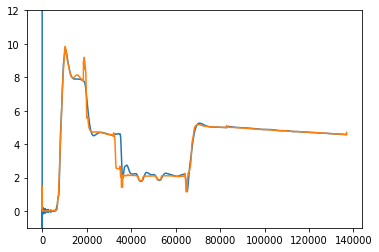

In [58]:
plt.plot(test_flight["Distance"], test_flight["vpath"])
plt.plot(test_flight["Distance"], y_pred)
plt.ylim([-1, 12])

# New Weight Model

In [145]:
thrust_model = keras.models.load_model("E://Models//model_thrust")
climb_angle_model = keras.models.load_model("E://Models//model_climb_angle")
scaler = load("E://Models//model_thrust//scaler.bin")

In [146]:
f_lst = []
d = r"E:\Stuff From Laptop\Polimi\Thesis\Stage 6 - Departure Data Generation Tests\747-400\Data\New\Test\13"
for (dirpath, dirnames, filenames) in os.walk(d):
    for f in filenames:
        f_lst.append(os.path.join(d,f))

In [147]:
def weight_loss(weight, df, thrust_model, climb_angle_model):
    df['weight'] = weight*np.ones(len(df))
    X = df[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "weight"]]
    thrust_pred = thrust_model.predict(X)
    X = copy.copy(df[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "weight"]])
    X["Thrust"] = thrust_pred
    climb_angle_pred = climb_angle_model.predict(X).reshape(len(df),)
    
    return np.sum(np.square(climb_angle_pred-df["vpath"].values))/len(df)

In [149]:
est_weight_lst = []
real_weight_lst = []
for f in f_lst[:100]:
#     print(f)
    test_flight = pd.read_csv(f)
    real_weight_lst.append(np.mean(test_flight["Total_Weight"]))
#     test_flight["theta"] = (test_flight["T_amb"] + 273.15)/298.15
    test_flight["Runway_Condition"] =test_flight.iloc[0]["Runway_Condition"]
    test_flight = test_flight[(test_flight["Distance"]>0) & (test_flight["Altitude_Above_Ground"]>=0)]
    test_flight.reset_index(inplace=True, drop=True)
    test_flight["Acceleration"] = 0
    for i in range(len(test_flight)):
        wind_dir = transform_angle(test_flight.loc[i, "Wind_Direction"]) - test_flight.loc[i, "Heading"]
        test_flight.loc[i, "Wind_dir_cos"] = np.cos(np.pi*wind_dir/180)
        test_flight.loc[i, "Wind_dir_sin"] = np.sin(np.pi*wind_dir/180)
        if i<(len(test_flight)-1):
            test_flight.loc[i, "Acceleration"] = (test_flight.loc[i+1, "Ground_Speed"] - test_flight.loc[i, "Ground_Speed"])/(test_flight.loc[i+1, "Time"] - test_flight.loc[i, "Time"])
    
    # Get the ADSB replica
#     test_flight_accurate, test_flight_ADSB = replicate_ADSB(test_flight)
    
    
    # ADSB data predictions
    flight_data = test_flight[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
    flight_data_scaled = pd.DataFrame(scaler.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
    
    # Weight Estimation
#     weight_0 = 0
#     optimized_params = optimize.minimize(weight_loss, [weight_0], bounds=[(-5,5)], args=(flight_data_scaled[test_flight_accurate["Distance"]>0], thrust_model, model), method="Nelder-mead", options={"fatol": 1e-8, "xatol": 1e-6})
    
    start_time = time.time()
    loss_lst = []
    w_acc = np.mean(flight_data_scaled["Total_Weight"])
    weight_test_arr = np.arange(w_acc-0.3,w_acc+0.3+1e-6,0.1)
    for weight in weight_test_arr:
        loss_lst.append(weight_loss(weight, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model))
        
    weight_test_arr = np.arange(weight_test_arr[max(np.argmin(loss_lst)-1,0)], weight_test_arr[min(np.argmin(loss_lst)+1, len(loss_lst)-1)]+1e-6, 0.01)
    loss_lst = []
    for weight in weight_test_arr:
        loss_lst.append(weight_loss(weight, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model))

    weight_test_arr = np.arange(weight_test_arr[max(np.argmin(loss_lst)-1,0)], weight_test_arr[min(np.argmin(loss_lst)+1, len(loss_lst)-1)]+1e-6, 0.01)
    loss_lst = []
    for weight in weight_test_arr:
        loss_lst.append(weight_loss(weight, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model))

    end_time = time.time()
#     print("Runtime = {:7.2f}".format(end_time-start_time))
#     print("X_opt = {:5.3f}".format(weight_test_arr[np.argmin(loss_lst)]))
    
    X_flight = flight_data_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight","Thrust"]]
#     flight_data_scaled.loc[:,"Total_Weight"] = np.ones(len(flight_data))*optimized_params.x
    flight_data_scaled.loc[:,"Total_Weight"] = np.ones(len(flight_data))*weight_test_arr[np.argmin(loss_lst)]
    output = scaler.inverse_transform(flight_data_scaled)
    est_weight_lst.append(np.mean(output[:,-2]))

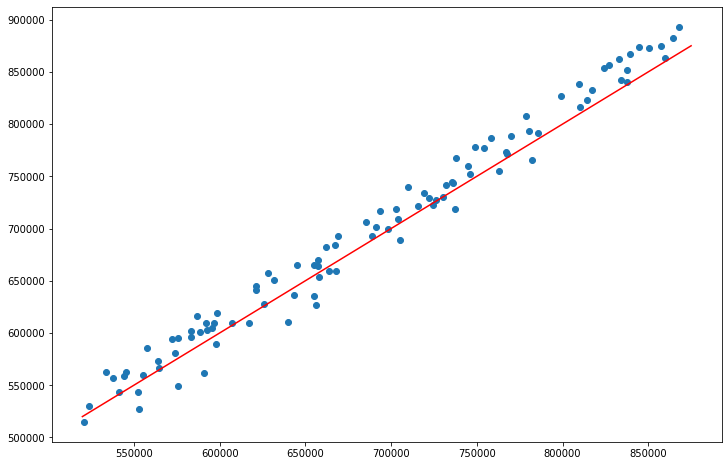

In [156]:
plt.figure(figsize=(12,8))
plt.scatter(real_weight_lst, est_weight_lst)
plt.plot([520000,875000],[520000,875000],"r")

In [152]:
np.mean(np.abs(np.array(real_weight_lst) - np.array(est_weight_lst)))

15290.67815397549

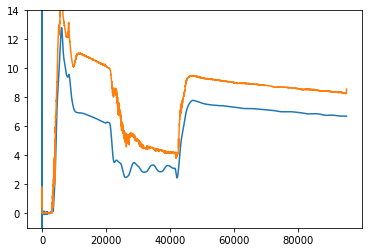

In [126]:
test_flight = pd.read_csv(f_lst[49])
# test_flight = pd.read_csv(r"E:\Stuff From Laptop\Polimi\Thesis\Stage 6 - Departure Data Generation\747-400\Data\10\2022-07-01---15-10-43.csv")
# test_flight["theta"] = (test_flight["T_amb"] + 273.15)/298.15
test_flight["Runway_Condition"] = test_flight.iloc[0]["Runway_Condition"]
test_flight["Acceleration"] = 0
for i in range(len(test_flight)):
    wind_dir = transform_angle(test_flight.loc[i, "Wind_Direction"]) - test_flight.loc[i, "Heading"]
    test_flight.loc[i, "Wind_dir_cos"] = np.cos(np.pi*wind_dir/180)
    test_flight.loc[i, "Wind_dir_sin"] = np.sin(np.pi*wind_dir/180)
    if i<(len(test_flight)-1):
        test_flight.loc[i, "Acceleration"] = (test_flight.loc[i+1, "Ground_Speed"] - test_flight.loc[i, "Ground_Speed"])/(test_flight.loc[i+1, "Time"] - test_flight.loc[i, "Time"])

flight_data = test_flight[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
# flight_data["Total_Weight"] = 818305.3756195507
flight_data_scaled = pd.DataFrame(scaler.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Runway_Condition", "Total_Weight", "Thrust"]]
X_flight["Total_Weight"] = -0.28
start_time = time.time()
y_pred_scaled = climb_angle_model.predict(X_flight).reshape(len(X_flight),)
output = scaler.inverse_transform(np.concatenate((X_flight.iloc[:,:6].values, y_pred_scaled.reshape(len(y_pred_scaled),1), X_flight.iloc[:, 6:].values), axis=1))
y_pred = output[:,6]
end_time = time.time()

plt.plot(test_flight["Distance"], test_flight["vpath"])
plt.plot(test_flight["Distance"], y_pred)
plt.ylim([-1, 14])
plt.show()

In [139]:
flight_data_scaled = flight_data_scaled[np.mod(test_flight["Time"],1)<0.1]

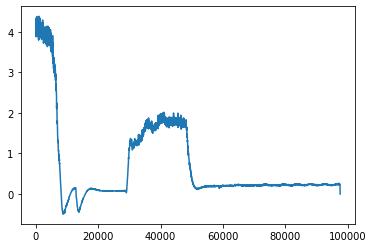

In [159]:
plt.plot(test_flight["Distance"], test_flight["Acceleration"])

In [163]:
mask_1 = np.flatnonzero((test_flight["Acceleration"]>1) & (test_flight["Altitude_Above_Ground"]>500))

In [166]:
mask_2 = np.flatnonzero(np.diff(mask_1)!=1)

In [169]:
np.mean(test_flight["CAS"])

219.13821251327926

In [161]:
test_flight[(test_flight["Acceleration"]>1) & (test_flight["Altitude_Above_Ground"]>500) & (test_flight["Altitude_Above_Ground"]<4000)]

,Time,Distance,Altitude_Above_Ground,Altitude_MSL,Latitude,Longitude,Throttle,Thrust,Thrust_Corrected,Engine_N1,...,Bank_C,Acc_C,sigma_TO,delta_TO,theta_TO,Wind_dir_cos_TO,Wind_dir_sin_TO,Thrust_TO,Distance_TO,Acceleration
915,122.429688,29904.855643,2612.450667,3394.380104,45.683804,8.723435,0.897679,36459.068287,42567.024710,89.699921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.024758
916,122.523438,29937.664042,2614.773928,3396.703365,45.683880,8.723444,0.897679,36452.594492,42563.146472,89.699921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.136210
917,122.609375,29970.472441,2617.009481,3398.938917,45.683956,8.723453,0.897679,36446.169874,42559.185802,89.699921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.074429
918,122.703125,30003.280840,2619.202181,3401.131617,45.684032,8.723461,0.897679,36439.639876,42555.033298,89.699921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.091830
919,122.796875,30036.089239,2621.324394,3403.253831,45.684105,8.723470,0.897679,36433.137980,42550.801074,89.699921,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.148146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1490,177.375000,48786.089239,3402.915214,4184.844650,45.739883,8.730430,0.897679,32507.534754,39089.860039,89.699875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.142768
1491,177.468750,48818.897638,3405.263706,4187.193142,45.740002,8.730444,0.897679,32502.055036,39086.706209,89.699875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.094045
1492,177.562500,48851.706037,3407.643836,4189.573273,45.740116,8.730458,0.897679,32496.677184,39083.720376,89.699875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.012224
1493,177.664062,48884.514436,3410.161737,4192.091173,45.740238,8.730473,0.897679,32491.151802,39080.757829,89.699875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.066836


In [33]:
plt.plot(flight_data[""])

array([1.])

In [627]:
np.mean(flight_data_scaled["Total_Weight"])

1.187018567847659

In [601]:
weight_loss(np.mean(flight_data_scaled["Total_Weight"]), flight_data_scaled[test_flight_accurate["Distance"]>0], thrust_model, model)

0.0007236360670197627

In [604]:
optimized_params.fun

0.02554432464016237

In [602]:
weight_loss(-0.24, flight_data_scaled[test_flight_accurate["Distance"]>0], thrust_model, model)

0.025546815152544065

In [603]:
weight_loss(-0.22, flight_data_scaled[test_flight_accurate["Distance"]>0], thrust_model, model)

0.025549012615709323

## Method 1

In [140]:
start_time = time.time()
loss_lst = []
weight_test_arr = np.arange(-3,3.00001,0.01)
for weight in weight_test_arr:
    loss_lst.append(weight_loss(weight, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model))

end_time = time.time()
print("Runtime = {:7.2f}".format(end_time-start_time))
print("X_opt = {:5.3f}".format(weight_test_arr[np.argmin(loss_lst)]))

Runtime =   51.71
X_opt = -0.330


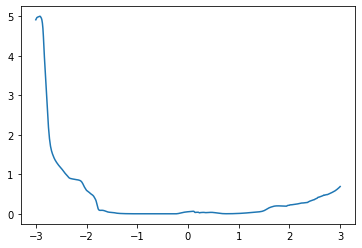

In [141]:
plt.plot(weight_test_arr, loss_lst)
plt.show()

In [101]:
weight_loss(np.mean(flight_data_scaled["Total_Weight"]), flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model)

0.007169541371823208

In [106]:
weight_loss(-0.28, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model)

0.0015164406370498625

In [110]:
weight_loss(0.6, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model)

0.022450661415518172

In [144]:
weight_test_arr[loss_lst==np.min(np.array(loss_lst)[weight_test_arr>0])]

array([0.77])

In [104]:
np.mean(flight_data_scaled["Total_Weight"])

0.7083494988851377

## Method 2

In [ ]:
start_time = time.time()
loss_lst = []
weight_test_arr = np.arange(-3,3.00001,0.1)
for weight in weight_test_arr:
    loss_lst.append(weight_loss(weight, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model))

weight_test_arr = np.arange(weight_test_arr[np.argmin(loss_lst)-1], weight_test_arr[np.argmin(loss_lst)+1]+1e-6, 0.01)
loss_lst = []
for weight in weight_test_arr:
    loss_lst.append(weight_loss(weight, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model))

weight_test_arr = np.arange(weight_test_arr[np.argmin(loss_lst)-1], weight_test_arr[np.argmin(loss_lst)+1]+1e-6, 0.001)
loss_lst = []
for weight in weight_test_arr:
    loss_lst.append(weight_loss(weight, flight_data_scaled[test_flight["Distance"]>0], thrust_model, climb_angle_model))

end_time = time.time()
print("Runtime = {:7.2f}".format(end_time-start_time))
print("X_opt = {:5.3f}".format(weight_test_arr[np.argmin(loss_lst)]))

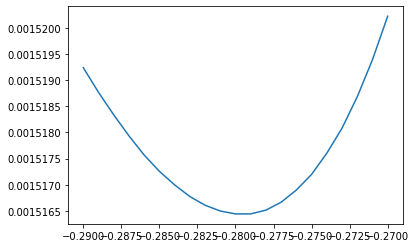

In [98]:
plt.plot(weight_test_arr, loss_lst)
plt.show()

In [77]:
np.argmin(loss_lst)

556

In [25]:
weight_test_arr[np.argmin(loss_lst)]

1.2799999999998661

In [613]:
loss_lst[629]

0.0004824078537125098

In [617]:
from geneticalgorithm import geneticalgorithm as ga

In [625]:
varbound=np.array([[-5,5]])
vartype=np.array([['real']])
algorithm_param = {'max_num_iteration': 100,\
                   'population_size':60,\
                   'mutation_probability':0.1,\
                   'elit_ratio': 0.01,\
                   'crossover_probability': 0.5,\
                   'parents_portion': 0.3,\
                   'crossover_type':'uniform',\
                   'max_iteration_without_improv':None}

In [626]:
ga_model=ga(function=weight_loss,dimension=1,variable_type_mixed=vartype,variable_boundaries=varbound,algorithm_parameters=algorithm_param)
ga_model.run()

TypeError: weight_loss() missing 3 required positional arguments: 'df', 'thrust_model', and 'climb_angle_model'